**벡터DB**
- 벡터 DB(Vector Database, 벡터 데이터베이스)는 전통적인 텍스트나 숫자 대신, **데이터의 의미와 문맥을 숫자의 배열(벡터, Vector, 임베딩값)**로 변환하여 저장하고 **유사도**로 검색하는 데 특화된 고성능 데이터베이스입니다.
- 기존의 관계형 DB(MySQL 등) DB는 키워드가 정확히 일치해야 데이터를 찾아냅니다. 반면 벡터 DB는 **말뜻(의미)이 통하는 것**을 찾아냅니다.
- LLM(대형 언어 모델)이 대중화되면서 AI가 데이터를 기억하고 검색하는 '장기 기억 장치(RAG)'로 필수적인 역할을 하고 있습니다.

- 임베딩 (Embedding): 비정형 데이터(텍스트, 이미지, 오디오 등)를 인공지능 모델을 거쳐 수백~수천 개의 숫자로 이루어진 좌표 값(벡터)으로 변환합니다. 이 과정에서 의미가 비슷한 데이터들은 3차원 공간상의 가까운 위치(좌표)에 모이게 됩니다.

- 벡터 DB 저장: 이렇게 변환된 고차원 좌표 데이터를 벡터 DB에 저장합니다.

- 유사도 검색 (Similarity Search): 사용자가 질문을 던지면 그 질문도 좌표(벡터)로 바꾼 뒤, 공간에서 가장 거리가 가까운 데이터들을 순식간에 찾아냅니다. (이때 코사인 유사도, 유클리드 거리 등의 수학적 계산법이 쓰입니다.)

**pgvector** 는 기존 데이터베이스(**postgresql**)에 벡터 검색 기능을 추가한 **확장형 벡터DB** 입니다.

[ 기동시키는 방법 ]
- 도커데스크탑을 실행
- 볼륨 생성(최초 한 번) : **docker volume create vpg** 
- pgvector 를 도커 컨테이너로 생성하고 기동 : **docker run -p 5432:5432 -d  -e POSTGRES_USER=edu -e POSTGRES_PASSWORD=1234  -e POSTGRES_DB=edudb  -v vpg:/var/lib/postgresql/data --name edupgvector ankane/pgvector** 
- 볼륨과 컨테이너가 이미 생성된 경우라면 : **docker start edupgvector**
- 도커 컨테이너 기동된 상황 채크 : **docker ps**

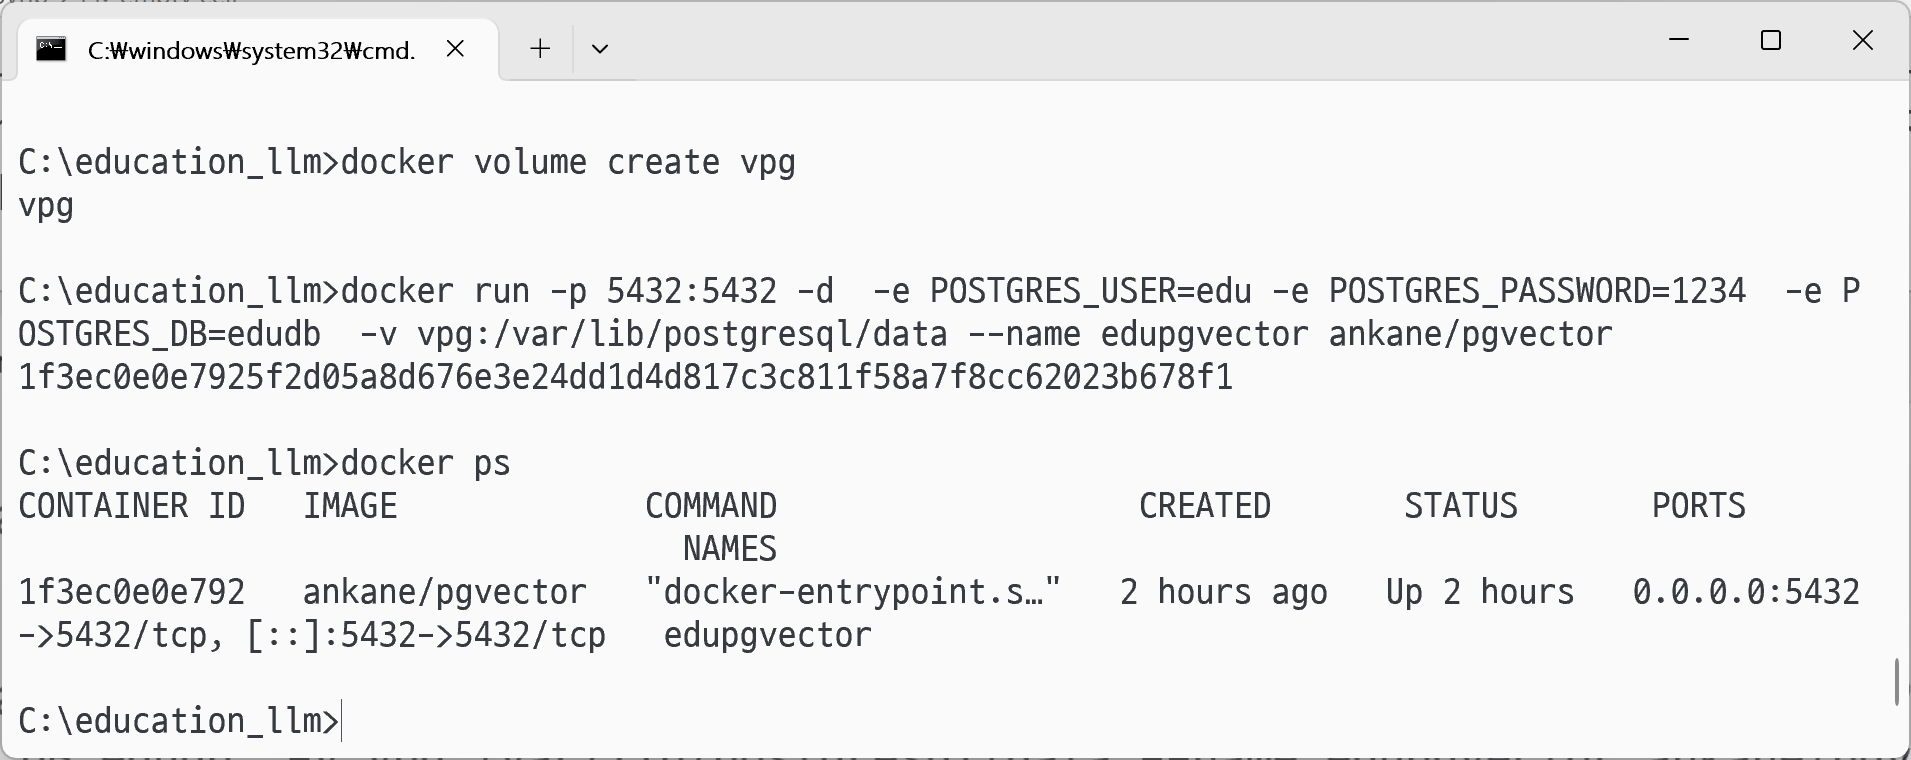

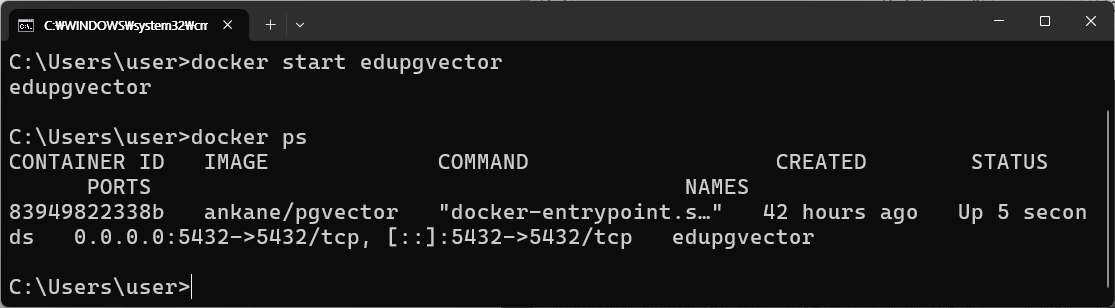

**벡터(vector)타입**
- 벡터는 단순히 방향과 크기를 가진 화살표라는 기하학적 의미를 넘어,  **데이터의 의미적 특징(Semantic Features)** 을 숫자 배열로 표현한 것입니다.
- 임베딩 벡터(Embedding Vector)라고도 부릅니다.
- 차원(Dimension, $N$): 벡터를 구성하는 숫자의 개수입니다. <br>
  OpenAI의 text-embedding-3-small 모델은 기본적으로 1,536 차원의 벡터 타입을 가집니다. <br>
  차원이 높을수록 데이터의 복잡한 의미를 더 정교하게 담을 수 있습니다.

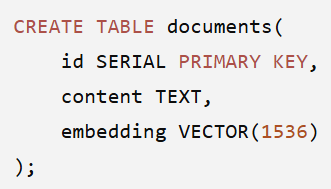

- 의미가 유사한 데이터는 고차원 공간에서 서로 가까이 위치한다 기하학적 가정 덕분에 벡터 DB는 두 벡터 데이터 간의 거리나 각도를 계산하여 유사도를 측정합니다.

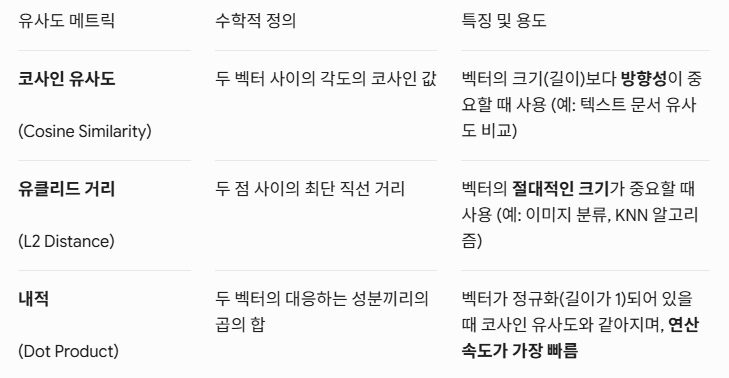

- pgvector 에서 지원하는 고차원 벡터간의 유사도 계산 연산자
- <=> : 코사인 거리 (Cosine Distance) -  벡터의 크기(길이)보다 두 벡터가 가리키는 방향이 얼마나 다른지를 봅니다.
- <-> : 유클리드 거리 (L2 Distance) - 기하학적인 직선 거리이며 두 벡터의 크기와 방향을 모두 고려합니다.
- <#> : 음수 내적 (Negative Dot Product) - 내적(Dot Product)은 값이 클수록 유사도가 높습니다. 내적 값에 마이너스(-)를 붙인 음수 내적 연산자를 사용합니다.


- **코사인 거리(Cosine Distance)**<br>
  embedding <=> query_vector
- **코사인 유사도(Cosine Similarity)**<br>
  1 - 코사인 거리

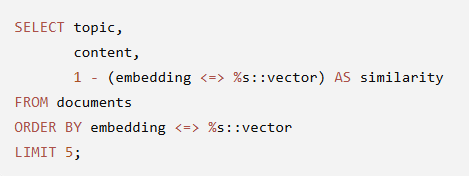  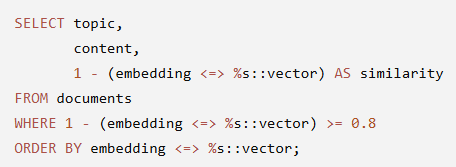   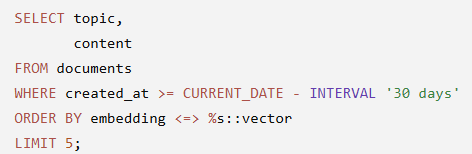

**실무에서 특히 기억하면 좋은 핵심 포인트**
- 거리(distance)와 유사도(similarity)를 구분하세요. <br>
  <=>는 유사도가 아니라 거리를 반환하므로 화면에 보여줄 때는 **1 - distance**처럼 변환해 사용합니다.
- 정렬은 항상 거리 기준으로 합니다. <br>
  **ORDER BY embedding <=> %s::vector LIMIT k** 형태가 pgvector 인덱스를 가장 잘 활용하는 기본 패턴입니다.
- 타입을 맞추는 것이 중요합니다. <br>
  Python에서 전달한 값이 numeric[]로 해석되면 vector와 연산할 수 없으므로 **%s::vector**와 같은 명시적 캐스팅합니다.
- 연산자와 인덱스는 함께 생각하세요. <br>
  코사인 거리(<=>)를 사용할 계획이라면 vector_cosine_ops 인덱스를, L2 거리(<->)라면 vector_l2_ops를 사용하는 것이 성능에 중요합니다.

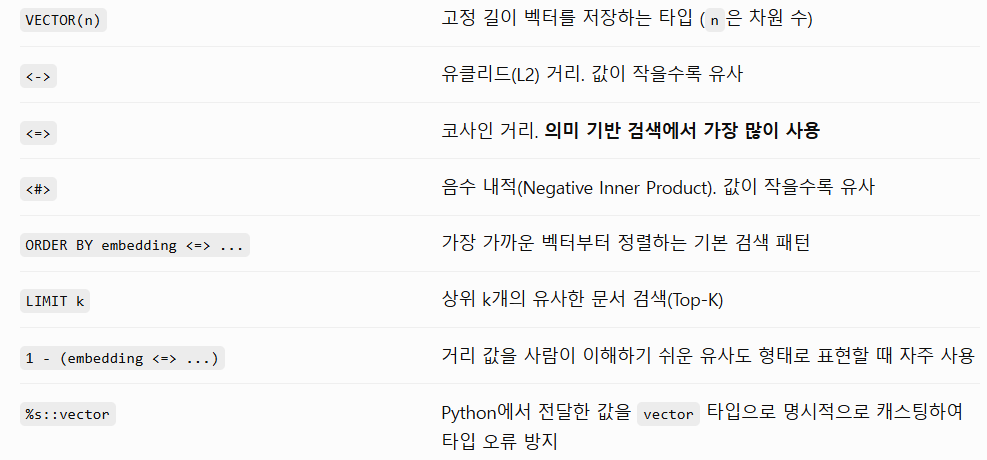

**임베딩한 벡터값 저장**

In [1]:
import os
from openai import OpenAI
import psycopg2  
from psycopg2.extras import execute_values  

# 1. 클라이언트 및 데이터베이스 연결 설정
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

# 도커로 띄우신 pgvector 연결 정보
DB_PARAMS = {
    "host": "localhost",
    "port": 5432,
    "user": "edu",
    "password": "1234",
    "database": "edudb"
}

# 2. 헬퍼 함수: text-embedding-3-small 모델로 임베딩 벡터 생성
def get_embedding(text):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    # 생성된 1536차원의 실수 배열(리스트)을 그대로 반환합니다.
    return response.data[0].embedding

# 3. 데이터베이스 초기화 및 데이터 저장 함수
def init_db_and_insert_documents():
    # 저장할 6개의 샘플 도큐먼트 (인공지능 교육 관련 내용)
    documents = [
        "AX(AI Transformation)는 기업 경영 전반에 인공지능을 도입하여 비즈니스 모델을 혁신하는 과정입니다.",
        "FastAPI는 파이썬 3.8+ 기반의 아주 빠르고 직관적인 최신 웹 프레임워크로, 비동기 처리에 강점이 있습니다.",
        "Docker Compose를 사용하면 여러 개의 컨테이너로 이루어진 개발 환경을 단 하나의 명령어로 깔끔하게 셋업할 수 있습니다.",
        "OpenAI의 text-embedding-3-small 모델은 텍스트를 1536차원의 고밀도 숫자 벡터로 변환해 줍니다.",
        "RAG(Retrieval-Augmented Generation)는 LLM이 가지는 환각 현상을 방지하기 위해 외부에 저장된 데이터베이스에서 관련 정보를 먼저 검색한 뒤 답변을 생성하는 기술입니다.",
        "김정현 강사는 유니코라는 별명을 가지고 있고 떡볶이를 좋아합니다. 광교에서 살고 있습니다."
    ]

    print("🔌 PostgreSQL 연결 중...")
    conn = psycopg2.connect(**DB_PARAMS)
    cur = conn.cursor()

    # 확장 기능 및 테이블 생성
    print("🛠️ pgvector 확장 기능 활성화 및 mydoc 테이블 생성 중...")
    cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
    
    # 기존 실습용 테이블 초기화
    cur.execute("DROP TABLE IF EXISTS mydoc;")
    
    # 테이블 구조 설계
    cur.execute("""
        CREATE TABLE mydoc (
            id SERIAL PRIMARY KEY,
            content TEXT,
            embedding vector(1536)
        );
    """)
    conn.commit()  # 구조 변경 반영

    # 도큐먼트를 순회하며 임베딩 벡터를 만들고 DB에 삽입
    print("🧠 도큐먼트 임베딩 변환 및 DB 저장 시작 (6개)...")
    data_to_insert = []
    for doc in documents:
        vector = get_embedding(doc)
        # 💡 psycopg2의 execute_values는 파이썬 순수 리스트(List)를 가공 없이 가장 잘 인식합니다!
        data_to_insert.append((doc, vector))
    
    # 💡 [안정성의 핵심] execute_values 구문에 %s 자리를 명시해 줍니다.
    # 복잡한 가공 없이 파이썬 리스트가 pgvector 포맷으로 가장 매끄럽게 컴파일되는 정석 문법입니다.
    print("💾 PostgreSQL에 벡터 데이터 저장 중...")
    execute_values(
        cur, 
        "INSERT INTO mydoc (content, embedding) VALUES %s", 
        data_to_insert
    )
    conn.commit()  # 최종 데이터 영구 저장
    print("✅ 5개의 도큐먼트가 벡터 데이터베이스에 성공적으로 저장되었습니다!\n")
    
    cur.close()
    conn.close()

In [2]:
init_db_and_insert_documents()

🔌 PostgreSQL 연결 중...
🛠️ pgvector 확장 기능 활성화 및 mydoc 테이블 생성 중...
🧠 도큐먼트 임베딩 변환 및 DB 저장 시작 (6개)...
💾 PostgreSQL에 벡터 데이터 저장 중...
✅ 5개의 도큐먼트가 벡터 데이터베이스에 성공적으로 저장되었습니다!



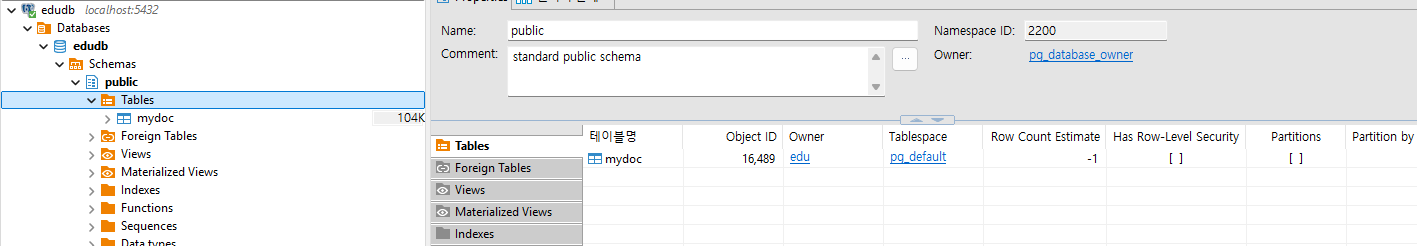

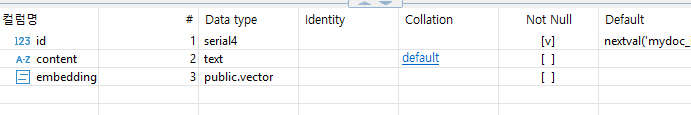

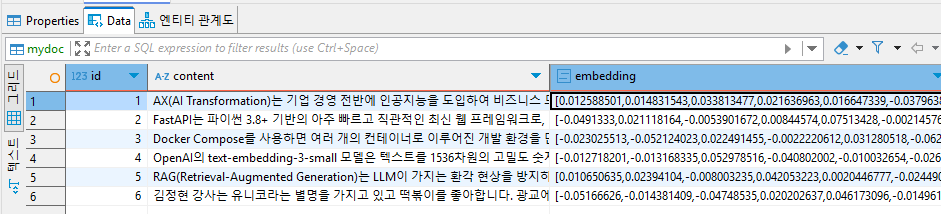

---

In [4]:
import os
import psycopg2
from openai import OpenAI
from pgvector.psycopg2 import register_vector
conn = None

In [5]:
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "edudb",
    "user": "edu",
    "password": "1234"
}
def get_conn():
    global conn
    conn = psycopg2.connect(**DB_CONFIG)
    register_vector(conn)
    return conn

In [6]:
EMBEDDING_MODEL = "text-embedding-3-small"

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def get_embedding(text):
    res = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=text
    )
    return res.data[0].embedding

In [7]:
def run_sql(title, sql, params):
    get_conn()
    print("=" * 70)
    print(title)
    print("=" * 70)

    conn = get_conn()

    try:
        with conn.cursor() as cur:
            cur.execute(sql, params)

            rows = cur.fetchall()

            for r in rows:
                print(r)

    finally:
        conn.close()

In [8]:
sql1 = """
SELECT content
FROM mydoc
ORDER BY embedding <=> %s::vector
LIMIT 3
"""

In [9]:
run_sql("TOP3", sql1, (get_embedding("별명"),))
run_sql("TOP3", sql1, (get_embedding("오뎅"),))

TOP3
('김정현 강사는 유니코라는 별명을 가지고 있고 떡볶이를 좋아합니다. 광교에서 살고 있습니다.',)
('RAG(Retrieval-Augmented Generation)는 LLM이 가지는 환각 현상을 방지하기 위해 외부에 저장된 데이터베이스에서 관련 정보를 먼저 검색한 뒤 답변을 생성하는 기술입니다.',)
('Docker Compose를 사용하면 여러 개의 컨테이너로 이루어진 개발 환경을 단 하나의 명령어로 깔끔하게 셋업할 수 있습니다.',)
TOP3
('김정현 강사는 유니코라는 별명을 가지고 있고 떡볶이를 좋아합니다. 광교에서 살고 있습니다.',)
('RAG(Retrieval-Augmented Generation)는 LLM이 가지는 환각 현상을 방지하기 위해 외부에 저장된 데이터베이스에서 관련 정보를 먼저 검색한 뒤 답변을 생성하는 기술입니다.',)
('Docker Compose를 사용하면 여러 개의 컨테이너로 이루어진 개발 환경을 단 하나의 명령어로 깔끔하게 셋업할 수 있습니다.',)


In [10]:
sql2 = """
SELECT content,
    1-(embedding <=> %s::vector) AS similarity
FROM mydoc
ORDER BY embedding <=> %s::vector
LIMIT 2
"""

In [11]:
emd = get_embedding("오뎅")
run_sql("Similarity", sql2, (emd,emd, ))

Similarity
('김정현 강사는 유니코라는 별명을 가지고 있고 떡볶이를 좋아합니다. 광교에서 살고 있습니다.', 0.16364591549014207)
('RAG(Retrieval-Augmented Generation)는 LLM이 가지는 환각 현상을 방지하기 위해 외부에 저장된 데이터베이스에서 관련 정보를 먼저 검색한 뒤 답변을 생성하는 기술입니다.', 0.14313448685147323)


In [12]:
sql = """
SELECT
    content,
    embedding <=> %s::vector AS distance,
    1-(embedding <=> %s::vector) AS similarity
FROM mydoc
ORDER BY distance;
"""

In [13]:
emd = get_embedding("집")
run_sql("Distance vs Similarity", sql,  (emd, emd))

Distance vs Similarity
('김정현 강사는 유니코라는 별명을 가지고 있고 떡볶이를 좋아합니다. 광교에서 살고 있습니다.', 0.7965999626449993, 0.20340003735500067)
('Docker Compose를 사용하면 여러 개의 컨테이너로 이루어진 개발 환경을 단 하나의 명령어로 깔끔하게 셋업할 수 있습니다.', 0.8467663329976381, 0.15323366700236185)
('RAG(Retrieval-Augmented Generation)는 LLM이 가지는 환각 현상을 방지하기 위해 외부에 저장된 데이터베이스에서 관련 정보를 먼저 검색한 뒤 답변을 생성하는 기술입니다.', 0.8707274821903868, 0.12927251780961324)
('AX(AI Transformation)는 기업 경영 전반에 인공지능을 도입하여 비즈니스 모델을 혁신하는 과정입니다.', 0.907767936118488, 0.09223206388151195)
('FastAPI는 파이썬 3.8+ 기반의 아주 빠르고 직관적인 최신 웹 프레임워크로, 비동기 처리에 강점이 있습니다.', 0.9289198744944299, 0.07108012550557008)
('OpenAI의 text-embedding-3-small 모델은 텍스트를 1536차원의 고밀도 숫자 벡터로 변환해 줍니다.', 0.9492738977774774, 0.05072610222252261)


---

**RAG 구현시 프롬프트**

<div>[참고 지식]: <br>
            {context}</div><br>
<div>[질문]: <br>
            {user_question}</div><br>
            
<div>지식을 참고해서 질문에 친절하게 한 문장으로 대답해줘. </div>

In [26]:
# 4. 핵심 RAG 수행 함수 (질문 ➔ 검색 ➔ Ollama 답변)
def ask_rag_question(user_question):
    print(f"❓ 사용자 질문: '{user_question}'")
    
    # 1단계: 사용자 질문도 동일한 모델로 임베딩 (벡터화)
    question_embedding = get_embedding(user_question)
    
    # 2단계: pgvector를 이용하여 질문 벡터와 가장 유사한 문서 1개 검색 (코사인 유사도 거리 연산자 <=> 사용)
    conn = psycopg2.connect(**DB_PARAMS)
    cur = conn.cursor()
    
    # 임베딩 거리가 가장 가까운(유사한) 상위 1개의 content를 뽑아옵니다.
    cur.execute("""
        SELECT content 
        FROM mydoc 
        ORDER BY embedding <=> %s::vector 
        LIMIT 1
    """, (question_embedding,))
    
    result = cur.fetchone()
    cur.close()
    conn.close()
    
    if not result:
        print("❌ 관련된 문서를 찾지 못했습니다.")
        return
        
    context = result[0]
    print(f"🔍 Vector DB에서 찾아낸 가장 관련 높은 지식(Context):\n   -> {context}\n")
    
    # 3단계: 찾아낸 지식(Context)을 뼈대로 삼아 Ollama(exaone3.5)에게 최종 답변 요청
    print("🤖 Ollama(exaone3.5)가 지식을 바탕으로 답변을 생성 중입니다...")
    
    # Ollama용 OpenAI 호환 클라이언트 설정 (exam1 노트북 방식)
    ollama_client = OpenAI(
        base_url="http://localhost:11434/v1",
        api_key="ollama"
    )
    
    response = ollama_client.chat.completions.create(
        model="exaone3.5",
        messages=[
            {"role": "system", "content": "너는 제공된 [참고 지식]만을 바탕으로 정직하게 답변하는 챗봇이야."},
            {"role": "user", "content": f"[참고 지식]: {context}\n\n[질문]: {user_question}\n\n지식을 참고해서 질문에 친절하게 한 문장으로 대답해줘."}
        ],
        temperature=0.3
    )
    
    ai_answer = response.choices[0].message.content
    print(f"✨ 최종 AI 답변:\n   -> {ai_answer}\n")


In [20]:
ask_rag_question("AX가 뭐지?")

❓ 사용자 질문: 'AX가 뭐지?'
🔍 Vector DB에서 찾아낸 가장 관련 높은 지식(Context):
   -> AX(AI Transformation)는 기업 경영 전반에 인공지능을 도입하여 비즈니스 모델을 혁신하는 과정입니다.

🤖 GPT-4o-mini가 지식을 바탕으로 답변을 생성 중입니다...


BadRequestError: Error code: 400 - {'error': {'message': "The requested model 'exaone3.5' does not exist.", 'type': 'invalid_request_error', 'param': 'model', 'code': 'model_not_found'}}

In [16]:
ask_rag_question("AI가 거짓말하는 환각 현상을 방지하려면 어떤 기술을 써야 해?")

❓ 사용자 질문: 'AI가 거짓말하는 환각 현상을 방지하려면 어떤 기술을 써야 해?'
🔍 Vector DB에서 찾아낸 가장 관련 높은 지식(Context):
   -> RAG(Retrieval-Augmented Generation)는 LLM이 가지는 환각 현상을 방지하기 위해 외부에 저장된 데이터베이스에서 관련 정보를 먼저 검색한 뒤 답변을 생성하는 기술입니다.

🤖 GPT-4o-mini가 지식을 바탕으로 답변을 생성 중입니다...
✨ 최종 AI 답변:
   -> AI의 거짓말하는 환각 현상을 방지하려면 RAG(Retrieval-Augmented Generation) 기술을 사용하여 외부 데이터베이스에서 관련 정보를 검색한 후 답변을 생성해야 합니다.



In [17]:
ask_rag_question("김정현 강사가 좋아하는 음식을 사가야해")

❓ 사용자 질문: '김정현 강사가 좋아하는 음식을 사가야해'
🔍 Vector DB에서 찾아낸 가장 관련 높은 지식(Context):
   -> 김정현 강사는 유니코라는 별명을 가지고 있고 떡볶이를 좋아합니다. 광교에서 살고 있습니다.

🤖 GPT-4o-mini가 지식을 바탕으로 답변을 생성 중입니다...
✨ 최종 AI 답변:
   -> 김정현 강사가 좋아하는 음식을 사가려면 떡볶이를 선택하면 좋을 것 같습니다.



In [ ]:
# 4. 핵심 RAG 수행 함수 (질문 ➔ 검색 ➔ GPT 답변)
def ask_rag_question(user_question):
    print(f"❓ 사용자 질문: '{user_question}'")
    
    # 1단계: 사용자 질문도 동일한 모델로 임베딩 (벡터화)
    question_embedding = get_embedding(user_question)
    
    # 2단계: pgvector를 이용하여 질문 벡터와 가장 유사한 문서 1개 검색 (코사인 유사도 거리 연산자 <=> 사용)
    conn = psycopg2.connect(**DB_PARAMS)
    cur = conn.cursor()
    
    # 임베딩 거리가 가장 가까운(유사한) 상위 1개의 content를 뽑아옵니다.
    cur.execute("""
        SELECT content 
        FROM mydoc 
        ORDER BY embedding <=> %s::vector 
        LIMIT 1
    """, (question_embedding,))
    
    result = cur.fetchone()
    cur.close()
    conn.close()
    
    if not result:
        print("❌ 관련된 문서를 찾지 못했습니다.")
        return
        
    context = result[0]
    print(f"🔍 Vector DB에서 찾아낸 가장 관련 높은 지식(Context):\n   -> {context}\n")
    
    # 3단계: 찾아낸 지식(Context)을 뼈대로 삼아 GPT-4o-mini에게 최종 답변 요청 (Prompt Engineering)
    print("🤖 GPT-4o-mini가 지식을 바탕으로 답변을 생성 중입니다...")
    response = client.responses.create(
        model="gpt-4o-mini",
        instructions = "너는 제공된 [참고 지식]만을 바탕으로 정직하게 답변하는 챗봇이야.",
        input = f"[참고 지식]: {context}\n\n[질문]: {user_question}\n\n지식을 참고해서 질문에 친절하게 한 문장으로 대답해줘.",        
        temperature=0.3
    )
    
    ai_answer = response.output_text
    print(f"✨ 최종 AI 답변:\n   -> {ai_answer}\n")

In [27]:
ask_rag_question("AX가 뭐지?")

❓ 사용자 질문: 'AX가 뭐지?'
🔍 Vector DB에서 찾아낸 가장 관련 높은 지식(Context):
   -> AX(AI Transformation)는 기업 경영 전반에 인공지능을 도입하여 비즈니스 모델을 혁신하는 과정입니다.

🤖 Ollama(exaone3.5)가 지식을 바탕으로 답변을 생성 중입니다...
✨ 최종 AI 답변:
   -> AX는 기업이 인공지능을 활용하여 경영 전반을 혁신하고 비즈니스 모델을 개선하는 과정을 의미합니다.



---

**항공이용가이드 RAG 챗봇**

In [ ]:
import os
import psycopg2 
from pgvector.psycopg2 import register_vector  
from openai import OpenAI

# docker run으로 띄운 pgvector 컨테이너 접속 정보
# 💡 psycopg2에서는 dbname 대신 database라는 키워드를 표준으로 사용하므로 변경했습니다.
DB_CONFIG = dict(host="localhost", port=5432, database="edudb", user="edu", password="1234")

EMBEDDING_MODEL = "text-embedding-3-small"
EMBEDDING_DIM = 1536

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))


def get_connection(register: bool = True):
    """
    DB 커넥션을 생성하고 pgvector 타입을 등록해서 반환한다.
    register_vector()는 DB에 'vector' 타입이 실제로 존재해야 동작하므로,
    아직 CREATE EXTENSION을 실행하기 전인 init_table()에서는 register=False로 호출한다.
    """
    # 💡 autocommit=True 모드로 연결을 엽니다.
    conn = psycopg2.connect(**DB_CONFIG)
    conn.autocommit = True
    
    if register:
        # 💡 psycopg2에서는 커넥션을 넘겨주면 내부적으로 알아서 벡터 타입을 올바르게 매핑합니다.
        register_vector(conn)
    return conn


def init_table():
    """pgvector 확장과 documents 테이블이 없으면 생성한다."""
    # ⚠️ 확장이 아직 없을 수 있는 시점이라 register_vector 없이 연결한다.
    conn = get_connection(register=False)
    try:
        with conn.cursor() as cur:
            cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
            cur.execute(
                f"""
                CREATE TABLE IF NOT EXISTS documents (
                    id SERIAL PRIMARY KEY,
                    topic TEXT NOT NULL,
                    content TEXT NOT NULL,
                    embedding VECTOR({EMBEDDING_DIM})
                );
                """
            )
    finally:
        conn.close()  # 💡 자원 반납을 명시적으로 처리


def get_embedding(text: str) -> list:
    """
    텍스트를 OpenAI 임베딩으로 변환한다.
    💡 psycopg2 환경에서는 별도의 Vector 오프셋 객체로 감쌀 필요 없이, 
       파이썬 순수 실수 리스트(list[float])를 그대로 리턴하면 제일 안전하게 바인딩됩니다.
    """
    response = client.embeddings.create(model=EMBEDDING_MODEL, input=text)
    return response.data[0].embedding


def search_knowledge_base(query: str, top_k: int = 3) -> list[dict]:
    """질문과 가장 관련 있는 항공 이용 안내 내용을 pgvector에서 검색한다."""
    query_vector = get_embedding(query)

    sql = """
        SELECT topic, content, 1 - (embedding <=> %s::vector) AS similarity
        FROM documents
        ORDER BY embedding <=> %s::vector
        LIMIT %s
    """

    conn = get_connection()
    try:
        with conn.cursor() as cur:
            # 💡 순수 리스트 데이터를 튜플 파라미터 구조로 안전하게 주입합니다.
            cur.execute(sql, (query_vector, query_vector, top_k))
            rows = cur.fetchall()
    finally:
        conn.close()  # 💡 조회가 끝난 후 커넥션을 확실하게 닫아줍니다.

    return [{"topic": r[0], "content": r[1], "similarity": round(r[2], 4)} for r in rows]

In [ ]:
"""
'항공이용가이드.pdf'를 주제 단위로 나눠 pgvector에 적재합니다.
"""
# 청크를 너무 크게 잡으면 검색 정확도가 떨어지고, 너무 잘게 나누면 맥락이 끊기므로 원문의 소제목 단위로 나눕니다.
DOCS = [
    ("항공권 예약 방법", "고객은 항공사 공식 홈페이지, 모바일 앱, 고객센터 전화, 여행사 및 온라인 여행 플랫폼을 통해 항공권을 예약할 수 있습니다. 예약 시 승객 이름(여권과 동일), 출발지 및 도착지, 여행 날짜, 좌석 등급(이코노미/프레스티지/일등석), 연락처 및 이메일을 입력해야 합니다."),
    ("항공권 예약 확인", "예약 후에는 홈페이지의 '예약 조회' 메뉴, 모바일 앱, 예약 확인 이메일, 또는 예약번호(PNR) 조회를 통해 예약 내용을 확인할 수 있습니다. 확인 시에는 예약번호와 승객 성명이 필요합니다."),
    ("항공권 변경 및 취소", "항공권은 운임 규정에 따라 변경 또는 취소가 가능합니다. 출발 전에는 변경이 가능하지만 일부 할인 운임은 변경 수수료가 발생합니다. 취소 시에는 환불 수수료가 발생할 수 있고, 출발 후 항공권은 일부 환불이 제한됩니다."),
    ("무료 위탁 수하물", "위탁 수하물 허용량은 좌석 등급과 노선에 따라 다릅니다. 이코노미는 23kg 1개, 프레스티지는 32kg 2개, 일등석은 32kg 3개까지 무료로 허용되며, 초과 시 추가 요금이 발생할 수 있습니다."),
    ("기내 반입 수하물", "기내에는 기내 가방 1개와 개인 소지품 1개(노트북 가방, 핸드백 등)를 반입할 수 있습니다. 일반적인 기준은 무게 약 10kg 이하, 크기는 좌석 위 수납 공간에 들어가는 정도입니다."),
    ("기내 반입 제한 물품 및 액체 규정", "날카로운 물건, 인화성 물질, 일부 액체류는 기내 반입이 제한됩니다. 액체류는 100ml 이하 용기에 담아 투명 지퍼백에 보관해야 하며, 총량은 1L를 넘을 수 없습니다."),
    ("공항 도착 권장 시간", "공항 도착 권장 시간은 노선에 따라 다릅니다. 국내선은 출발 1시간 전, 국제선은 출발 2~3시간 전까지 공항에 도착하는 것을 권장합니다."),
    ("체크인 방법", "체크인은 공항 체크인 카운터, 키오스크 체크인, 모바일 체크인, 웹 체크인 중 한 가지 방법으로 할 수 있습니다. 체크인 시에는 여권(국제선의 경우), 예약번호, 항공권 정보가 필요합니다."),
    ("탑승 절차", "탑승 과정은 체크인, 수하물 위탁, 보안 검색, 출국 심사(국제선의 경우), 탑승 게이트 이동, 항공기 탑승 순서로 진행됩니다."),
    ("기내 식사 서비스", "기내 식사는 비행 시간과 노선에 따라 제공됩니다. 장거리 노선은 식사가 2회, 중거리 노선은 1회 제공되며, 단거리 노선에서는 간식이나 음료가 제공됩니다. 채식, 어린이식, 종교식, 저염식 같은 특별식은 보통 출발 24시간 전까지 요청해야 합니다."),
    ("기내 엔터테인먼트", "기내에서는 영화, TV 프로그램, 음악, 게임 등 다양한 콘텐츠를 이용할 수 있습니다. 일부 항공기에서는 개인 좌석 스크린이 제공됩니다."),
    ("기내 인터넷(Wi-Fi)", "일부 항공기에서는 Wi-Fi 서비스를 통해 메시징, 인터넷 브라우징, 이메일 확인이 가능합니다. 이용 요금은 노선과 사용 시간에 따라 다를 수 있습니다."),
    ("좌석 종류 및 선택", "좌석은 기본 좌석인 이코노미, 넓고 침대형인 프레스티지, 최고급 서비스인 일등석으로 나뉩니다. 좌석은 예약 시 또는 체크인 시 선택할 수 있으며, 일부 좌석은 추가 요금이 발생할 수 있습니다."),
    ("특별 승객 서비스", "유아 동반 승객, 어린이 단독 여행, 임산부, 장애 승객, 휠체어 이용 고객을 위한 서비스가 제공되며, 이런 서비스는 사전 요청이 필요할 수 있습니다."),
    ("고객 지원", "고객은 고객센터 전화, 공항 서비스 데스크, 홈페이지 문의, 모바일 앱 채팅을 통해 도움을 받을 수 있습니다. 긴급 상황이나 항공편 변경이 필요할 때는 고객센터로 전화하는 것이 가장 빠릅니다."),
]


def seed():
    init_table()  # 테이블이 없으면 먼저 생성

    with get_connection() as conn:
        with conn.cursor() as cur:
            cur.execute("DELETE FROM documents;")  # 재실행 시 중복 적재 방지

            for topic, content in DOCS:
                embedding = get_embedding(content)
                cur.execute(
                    "INSERT INTO documents (topic, content, embedding) VALUES (%s, %s, %s)",
                    (topic, content, embedding),
                )

    print(f"[SEED] 총 {len(DOCS)}개 주제를 pgvector에 적재했습니다.")

In [ ]:
seed()

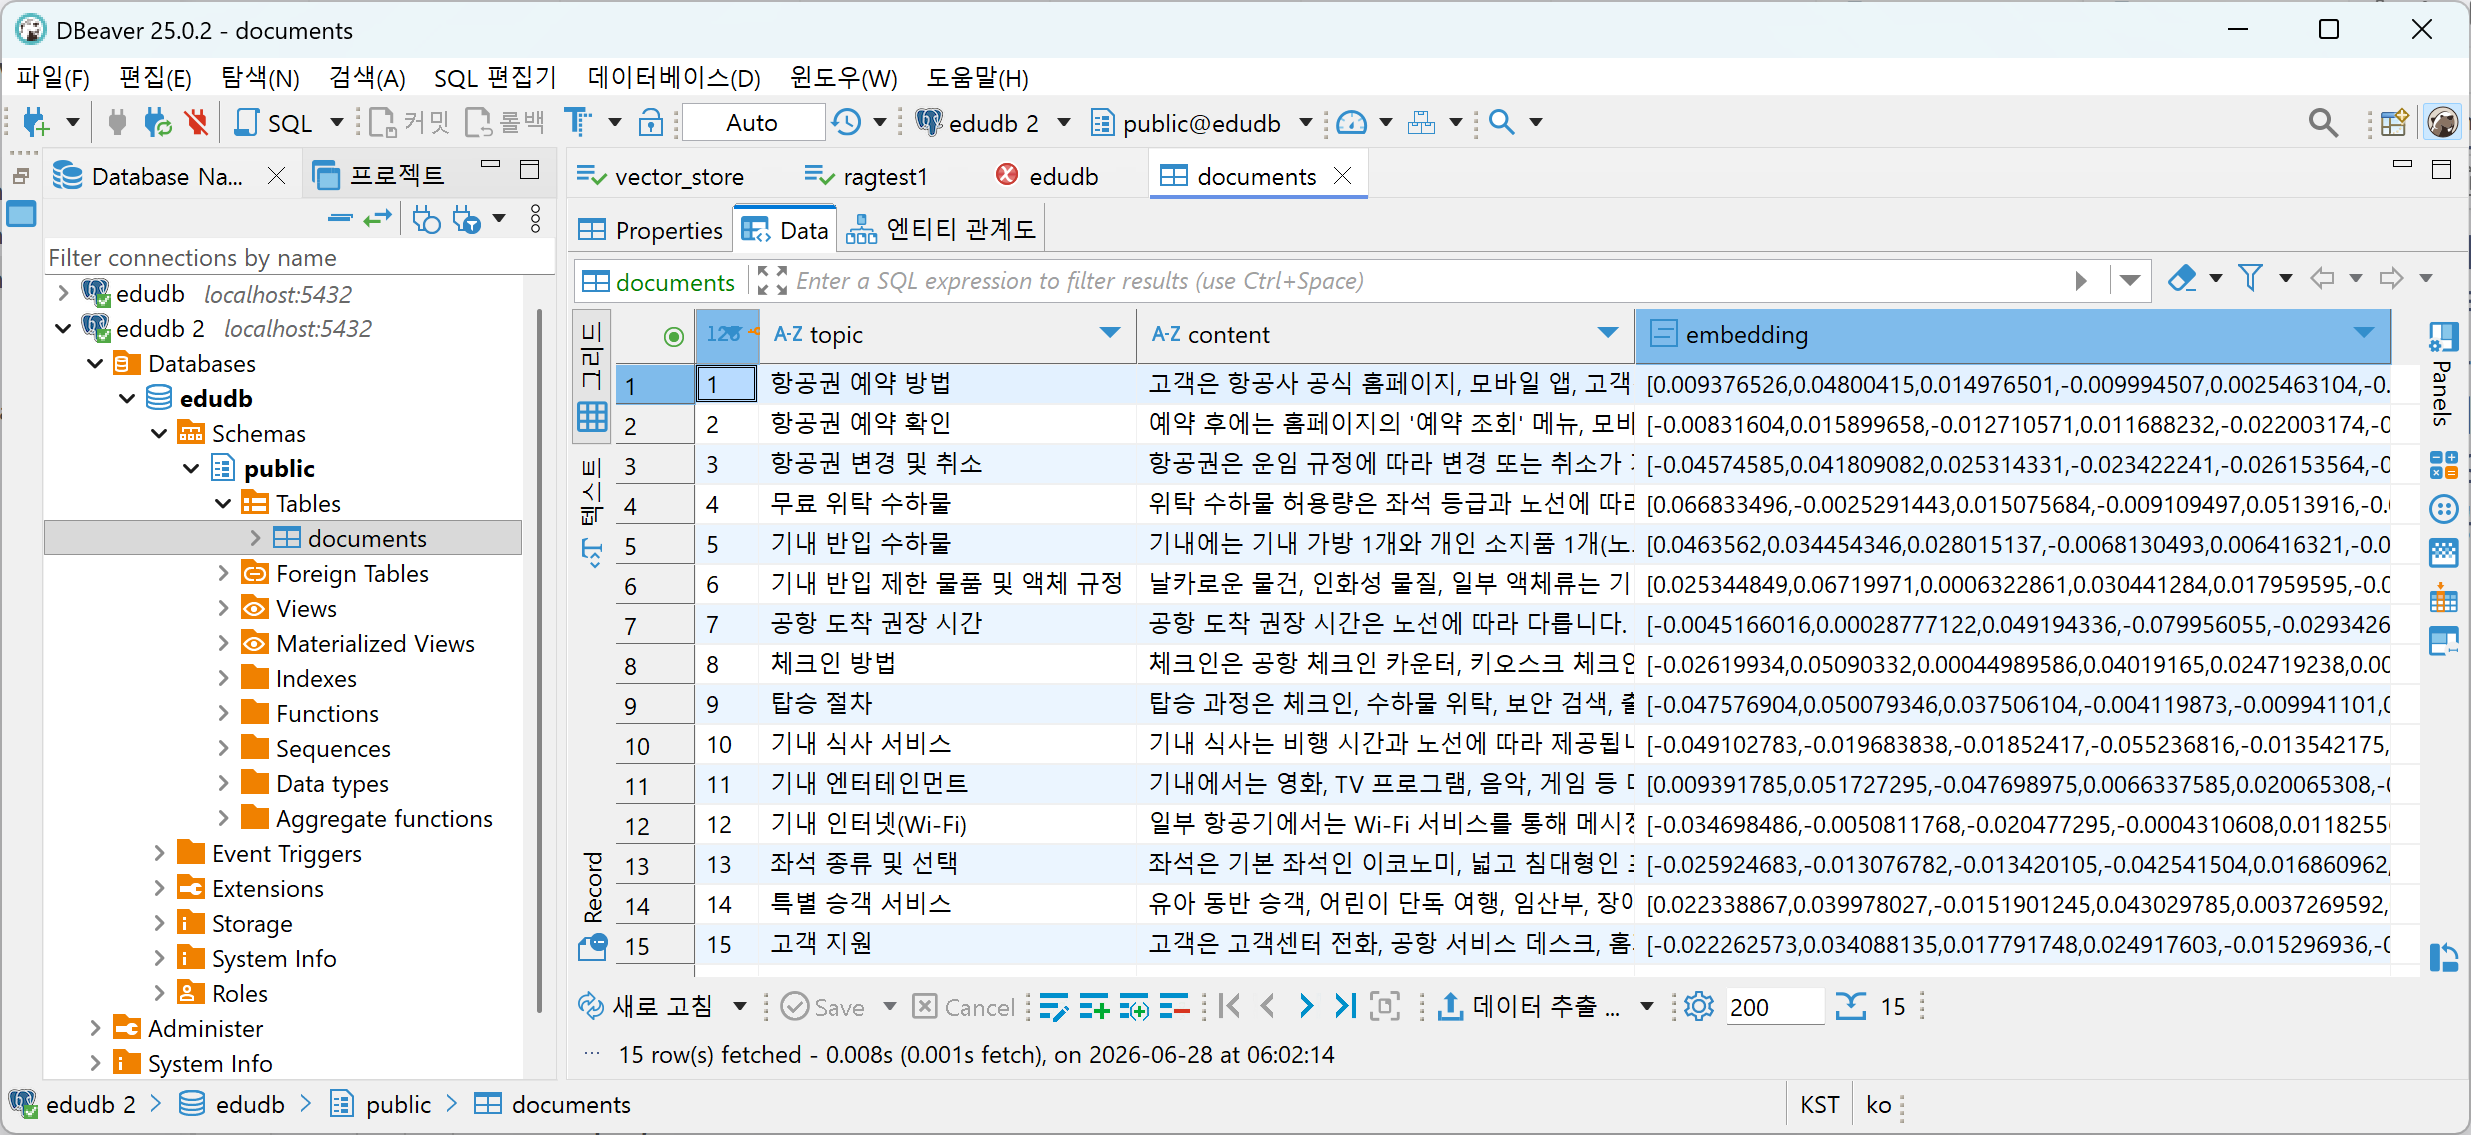

In [ ]:
question = "배가고파서.. 탑승하면 음식을 빨리 먹을 수 있음 좋겠다"
results = search_knowledge_base(question, top_k=3)
 
print(f"\n'{question}'와 유사한 청크 {len(results)}개\n" + "-" * 40)
for i, r in enumerate(results, 1):
    print(f"{i}. [{r['topic']}]  (유사도 {r['similarity']})")
    print(f"   {r['content']}\n")

In [ ]:
%pip install pypdf

In [ ]:
import os
from openai import OpenAI
import psycopg2  
from psycopg2.extras import execute_values 
from pypdf import PdfReader

# 1. OpenAI 클라이언트 및 데이터베이스 설정
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

DB_PARAMS = {
    "host": "localhost",
    "port": 5432,
    "user": "edu",
    "password": "1234",
    "database": "edudb"
}

# 2. 헬퍼 함수: OpenAI text-embedding-3-small 벡터 생성 (1536차원)
def get_embedding(text):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=text
    )
    # 파이썬 순수 실수 리스트(list[float])를 그대로 리턴합니다.
    return response.data[0].embedding

# 3. PDF 로드 및 적응형 청크 분할 함수
def prepare_chunks_from_pdf(pdf_path, overlap_size=200):
    print(f"📖 PDF 파일 읽는 중: {pdf_path}")
    reader = PdfReader(pdf_path)
    
    chunks = []
    previous_context = "" # 앞 페이지 뒷부분을 기억할 변수
    
    for idx, page in enumerate(reader.pages):
        page_num = idx + 1
        raw_text = page.extract_text()
        
        if not raw_text.strip():
            continue
            
        # 불필요하게 반복되는 공백 및 줄바꿈 정제
        cleaned_text = " ".join(raw_text.split())
        
        # 앞 페이지의 오버랩 텍스트와 현재 페이지 텍스트 결합 (문맥 보존)
        if previous_context:
            chunk_content = f"...{previous_context} {cleaned_text}"
        else:
            chunk_content = cleaned_text
            
        # 청크 리스트에 페이지 메타데이터와 함께 저장
        chunks.append({
            "page": page_num,
            "content": chunk_content
        })
        
        # 다음 페이지를 위해 현재 페이지의 마지막 부분을 오버랩 사이즈만큼 보관
        previous_context = cleaned_text[-overlap_size:] if len(cleaned_text) > overlap_size else cleaned_text

    print(f"📝 총 {len(chunks)}개의 페이지 기반 청크가 생성되었습니다.")
    return chunks

# 4. 데이터베이스 초기화 및 데이터 대량 삽입 함수
def store_pdf_to_vector_db(pdf_path):
    # 1단계: PDF에서 문맥을 고려하여 청크 추출
    chunks = prepare_chunks_from_pdf(pdf_path)
    
    # 2단계: 데이터베이스 커넥션 생성 및 autocommit 설정
    conn = psycopg2.connect(**DB_PARAMS)
    conn.autocommit = True  # 💡 전통적인 방식으로 수동 설정하여 안정적인 커밋 유도
    cur = conn.cursor()
    
    print("🛠️ pgvector 확장 기능 확인 및 erpdocuments 테이블 생성 중...")
    cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")
    cur.execute("DROP TABLE IF EXISTS erpdocuments;")
    
    # 테이블 설계
    cur.execute("""
        CREATE TABLE erpdocuments (
            id SERIAL PRIMARY KEY,
            page INTEGER,
            content TEXT,
            embedding vector(1536)
        );
    """)
    
    # 3단계: 각 청크별 임베딩 생성 후 저장용 리스트 구축
    print("🧠 OpenAI 대량 임베딩 요청 시작 (text-embedding-3-small)...")
    data_to_insert = []
    
    for chunk in chunks:
        embedding_vector = get_embedding(chunk["content"])
        
        # 💡 psycopg2의 execute_values에 맞게 튜플로 한 쌍씩 쌓아줍니다.
        data_to_insert.append((
            chunk["page"],
            chunk["content"],
            embedding_vector
        ))
        print(f"   -> [성공] {chunk['page']} 페이지 임베딩 완료")
        
    # 4단계: 💡 [가장 안전한 핵심 수정] psycopg2 방식의 execute_values로 대량 벌크 인서트
    print("💾 PostgreSQL에 벡터 데이터 저장 중...")
    execute_values(
        cur,
        "INSERT INTO erpdocuments (page, content, embedding) VALUES %s",
        data_to_insert
    )
    
    cur.close()
    conn.close()
    print("🎉 erp.pdf 백서의 모든 지식이 벡터 데이터베이스에 성공적으로 이관되었습니다!")


In [ ]:
PDF_FILE_PATH = "data/erp.pdf"
    
if os.path.exists(PDF_FILE_PATH):
    store_pdf_to_vector_db(PDF_FILE_PATH)
else:
    print(f"❌ {PDF_FILE_PATH} 파일이 존재하지 않습니다. 경로를 확인해 주세요.")

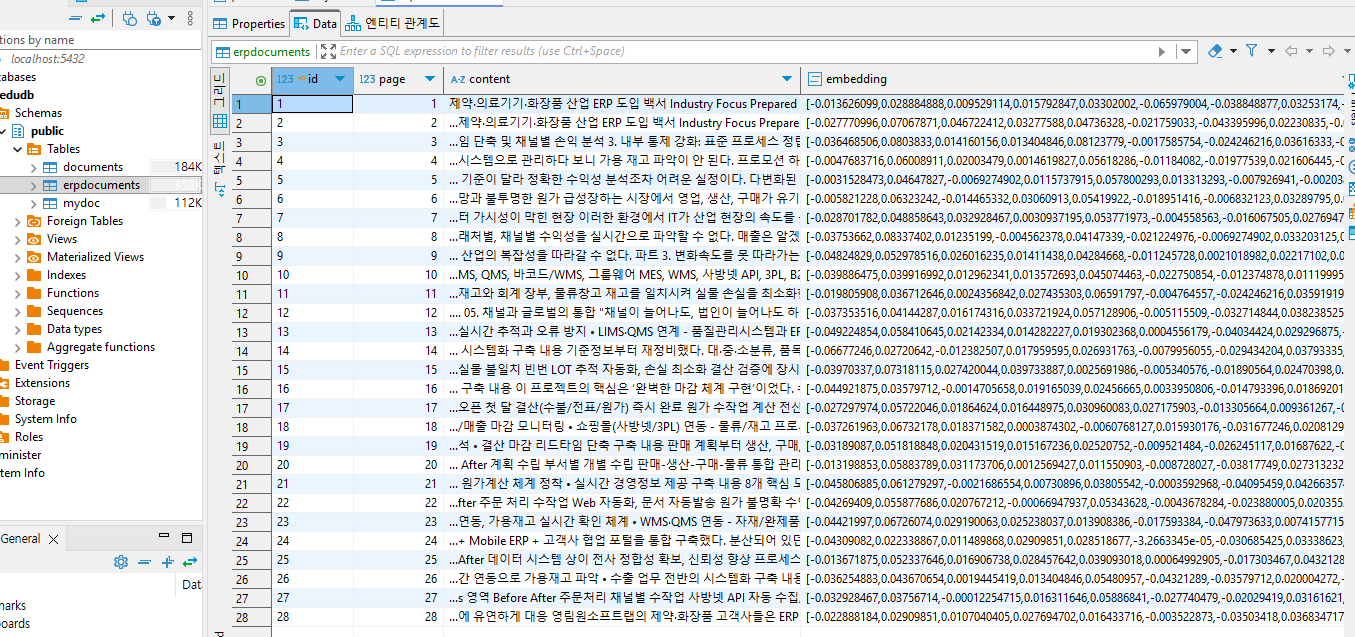

---